# Tugas Besar DKA: Perbandingan Metode Fuzzy Mamdani dan Sugeno pada Sistem Rekomendasi Restoran (Scikit-Fuzzy Version)

**Mata Kuliah:** Dasar Komputasi Algoritma (DKA)  
**Topik:** Sistem Rekomendasi Restoran Berbasis Fuzzy Logic  
**Metode:** Fuzzy Mamdani vs Fuzzy Sugeno (Implementasi Berbasis Library Scikit-Fuzzy)

---

In [15]:
# Tugas Besar DKA: Perbandingan Metode Fuzzy Mamdani dan Sugeno 
# Sistem Rekomendasi Restoran

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Data Loading & Preprocessing (Dataset Real Zomato)

In [20]:
# Memuat data Zomato
df = pd.read_csv('zomato.csv', encoding='latin-1')
print("Jumlah baris dan kolom dataset asli:", df.shape)

# Preprocessing kolom yang digunakan
cols = ['Restaurant Name', 'Average Cost for two', 'Price range',
        'Votes', 'Has Table booking', 'Has Online delivery', 'Aggregate rating']
data = df[cols].copy()

# Filter data: Hapus rating 0 & ubah kategorikal Yes/No menjadi numerik biner (1/0)
data = data[data['Aggregate rating'] > 0]
data['Has Table booking'] = data['Has Table booking'].map({'Yes': 1, 'No': 0})
data['Has Online delivery'] = data['Has Online delivery'].map({'Yes': 1, 'No': 0})
data = data.dropna().reset_index(drop=True)

print("Jumlah data setelah preprocessing siap pakai:", data.shape)
display(data.head())

Jumlah baris dan kolom dataset asli: (9551, 21)
Jumlah data setelah preprocessing siap pakai: (7403, 7)


,Restaurant Name,Average Cost for two,Price range,Votes,Has Table booking,Has Online delivery,Aggregate rating
0,Le Petit Souffle,1100,3,314,1,0,4.8
1,Izakaya Kikufuji,1200,3,591,1,0,4.5
2,Heat - Edsa Shangri-La,4000,4,270,1,0,4.4
3,Ooma,1500,4,365,0,0,4.9
4,Sambo Kojin,1500,4,229,1,0,4.8


## 2. Menentukan Nilai Breakpoint (Batas Fungsi)

In [19]:
max_cost = int(data['Average Cost for two'].max())
max_votes = int(data['Votes'].max())

def get_breakpoints(series):
    return {
        'min': series.min(),
        'p25': series.quantile(0.25),
        'p50': series.quantile(0.50),
        'p75': series.quantile(0.75),
        'max': series.max()
    }

bp_cost  = get_breakpoints(data['Average Cost for two'])
bp_votes = get_breakpoints(data['Votes'])

print("Breakpoints Harga:", bp_cost)
print("Breakpoints Votes:", bp_votes)

Breakpoints Harga: {'min': 0, 'p25': np.float64(300.0), 'p50': np.float64(500.0), 'p75': np.float64(800.0), 'max': 800000}
Breakpoints Votes: {'min': 4, 'p25': np.float64(19.0), 'p50': np.float64(60.0), 'p75': np.float64(181.0), 'max': 10934}


## 3. Fuzzifikasi (Pembuatan Fungsi Keanggotaan)

In [24]:
# Rumus Trapesium
def trap_mf(x, a, b, c, d):
    if x <= a or x >= d:
        return 0.0
    elif a < x < b:
        return (x - a) / (b - a) if b != a else 1.0
    elif b <= x <= c:
        return 1.0
    elif c < x < d:
        return (d - x) / (d - c) if d != c else 1.0
    return 0.0

# Rumus Segitiga
def tri_mf(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    elif a < x <= b:
        return (x - a) / (b - a) if b != a else 1.0
    elif b < x < c:
        return (c - x) / (c - b) if c != b else 1.0
    return 0.0

# Fuzzifikasi Input
def fuzzify_harga(x):
    return {
        'murah': trap_mf(x, bp_cost['min'], bp_cost['min'], bp_cost['p25'], bp_cost['p50']),
        'sedang': tri_mf(x, bp_cost['p25'], bp_cost['p50'], bp_cost['p75']),
        'mahal': trap_mf(x, bp_cost['p50'], bp_cost['p75'], bp_cost['max'], bp_cost['max'])
    }

def fuzzify_votes(x):
    return {
        'sedikit': trap_mf(x, bp_votes['min'], bp_votes['min'], bp_votes['p25'], bp_votes['p50']),
        'sedang': tri_mf(x, bp_votes['p25'], bp_votes['p50'], bp_votes['p75']),
        'banyak': trap_mf(x, bp_votes['p50'], bp_votes['p75'], bp_votes['max'], bp_votes['max'])
    }

def fuzzify_price_range(x):
    return {
        'rendah': trap_mf(x, 1, 1, 1, 2),
        'sedang': tri_mf(x, 1, 2, 3),
        'tinggi': trap_mf(x, 2, 3, 4, 4)
    }

def fuzzify_boolean(x):
    return {
        'tidak': tri_mf(x, 0, 0, 1),
        'ya': tri_mf(x, 0, 1, 1)
    }

## 4. Visualisasi Plot Fungsi Keanggotaan

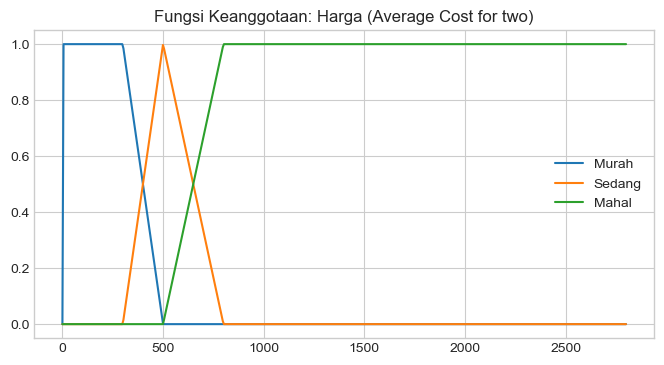

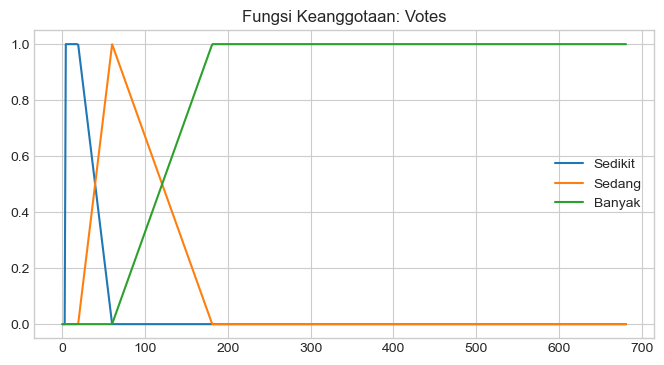

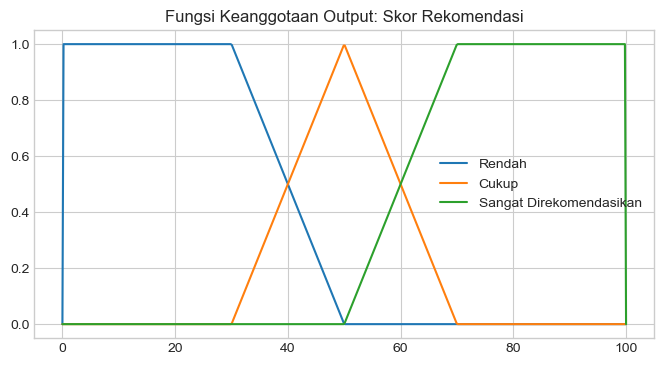

In [25]:
# 1. Plot Harga
x_harga = np.linspace(0, bp_cost['p75'] + 2000, 500) 
y_harga_murah = [trap_mf(x, bp_cost['min'], bp_cost['min'], bp_cost['p25'], bp_cost['p50']) for x in x_harga]
y_harga_sedang = [tri_mf(x, bp_cost['p25'], bp_cost['p50'], bp_cost['p75']) for x in x_harga]
y_harga_mahal = [trap_mf(x, bp_cost['p50'], bp_cost['p75'], bp_cost['max'], bp_cost['max']) for x in x_harga]

plt.figure(figsize=(8, 4))
plt.plot(x_harga, y_harga_murah, label='Murah')
plt.plot(x_harga, y_harga_sedang, label='Sedang')
plt.plot(x_harga, y_harga_mahal, label='Mahal')
plt.title('Fungsi Keanggotaan: Harga (Average Cost for two)')
plt.legend()
plt.show()

# 2. Plot Votes
x_votes = np.linspace(0, bp_votes['p75'] + 500, 500)
y_votes_sedikit = [trap_mf(x, bp_votes['min'], bp_votes['min'], bp_votes['p25'], bp_votes['p50']) for x in x_votes]
y_votes_sedang = [tri_mf(x, bp_votes['p25'], bp_votes['p50'], bp_votes['p75']) for x in x_votes]
y_votes_banyak = [trap_mf(x, bp_votes['p50'], bp_votes['p75'], bp_votes['max'], bp_votes['max']) for x in x_votes]

plt.figure(figsize=(8, 4))
plt.plot(x_votes, y_votes_sedikit, label='Sedikit')
plt.plot(x_votes, y_votes_sedang, label='Sedang')
plt.plot(x_votes, y_votes_banyak, label='Banyak')
plt.title('Fungsi Keanggotaan: Votes')
plt.legend()
plt.show()

# 3. Plot Output Rekomendasi
x_out = np.linspace(0, 100, 500)
y_out_rendah = [trap_mf(x, 0, 0, 30, 50) for x in x_out]
y_out_cukup = [tri_mf(x, 30, 50, 70) for x in x_out]
y_out_sangat = [trap_mf(x, 50, 70, 100, 100) for x in x_out]

plt.figure(figsize=(8, 4))
plt.plot(x_out, y_out_rendah, label='Rendah')
plt.plot(x_out, y_out_cukup, label='Cukup')
plt.plot(x_out, y_out_sangat, label='Sangat Direkomendasikan')
plt.title('Fungsi Keanggotaan Output: Skor Rekomendasi')
plt.legend()
plt.show()

## 5. Inferensi (dengan 17 Rules)

In [27]:
def inferensi(fz_harga, fz_votes, fz_price, fz_book, fz_deliv):
    # Evaluasi 17 Rules dengan fungsi MIN (operator AND)
    rules = [
        ('Sangat', min(fz_harga['murah'], fz_votes['banyak'])),
        ('Cukup', min(fz_harga['murah'], fz_votes['sedang'])),
        ('Cukup', min(fz_harga['murah'], fz_votes['sedikit'])),
        
        ('Sangat', min(fz_harga['sedang'], fz_votes['banyak'])),
        ('Cukup', min(fz_harga['sedang'], fz_votes['sedang'])),
        ('Rendah', min(fz_harga['sedang'], fz_votes['sedikit'])),
        
        ('Cukup', min(fz_harga['mahal'], fz_votes['banyak'])),
        ('Rendah', min(fz_harga['mahal'], fz_votes['sedang'])),
        ('Rendah', min(fz_harga['mahal'], fz_votes['sedikit'])),
        
        ('Sangat', min(fz_price['rendah'], fz_votes['banyak'])),
        ('Rendah', min(fz_price['tinggi'], fz_votes['sedikit'])),
        ('Cukup', min(fz_price['sedang'], fz_votes['sedang'])),
        
        ('Sangat', min(fz_book['ya'], fz_deliv['ya'])),
        ('Rendah', min(fz_book['tidak'], fz_deliv['tidak'], fz_votes['sedikit'])),
        ('Cukup', min(fz_book['ya'], fz_votes['sedang'])),
        
        ('Sangat', min(fz_deliv['ya'], fz_harga['murah'])),
        ('Rendah', min(fz_book['tidak'], fz_harga['mahal']))
    ]
    
    # Agregasi untuk Mamdani menggunakan fungsi MAX
    agg_mamdani = {'Rendah': 0.0, 'Cukup': 0.0, 'Sangat': 0.0}
    for label, alpha in rules:
        agg_mamdani[label] = max(agg_mamdani[label], alpha)
        
    return agg_mamdani, rules

## 6. Defuzzifikasi (Mamdani & Sugeno)

In [28]:
def defuzz_mamdani(agg_mamdani):
    num = 0.0
    den = 0.0
    # Integral numerik diskrit dari domain 0 sampai 100
    for x in range(0, 101):
        mu_Rendah = min(agg_mamdani['Rendah'], trap_mf(x, 0, 0, 30, 50))
        mu_Cukup = min(agg_mamdani['Cukup'], tri_mf(x, 30, 50, 70))
        mu_Sangat = min(agg_mamdani['Sangat'], trap_mf(x, 50, 70, 100, 100))
        
        # Luasan gabungan menggunakan max()
        mu_max = max(mu_Rendah, mu_Cukup, mu_Sangat)
        
        num += x * mu_max
        den += mu_max
        
    return num / den if den != 0 else 50.0

def defuzz_sugeno(rules):
    # Nilai konstanta singleton untuk Sugeno
    sugeno_const = {'Rendah': 20, 'Cukup': 50, 'Sangat': 85}
    num = 0.0
    den = 0.0
    
    for label, alpha in rules:
        num += alpha * sugeno_const[label]
        den += alpha
        
    return num / den if den != 0 else 50.0

## 7. Eksekusi Perhitungan Fuzzy pada Dataset

In [31]:
mamdani_scores = []
sugeno_scores = []

print("Memulai perhitungan fuzzy pada seluruh baris dataset...")
start_time = time.time()

for idx, row in data.iterrows():
    # 1. Fuzzifikasi
    fz_harga = fuzzify_harga(row['Average Cost for two'])
    fz_votes = fuzzify_votes(row['Votes'])
    fz_price = fuzzify_price_range(row['Price range'])
    fz_book  = fuzzify_boolean(row['Has Table booking'])
    fz_deliv = fuzzify_boolean(row['Has Online delivery'])
    
    # 2. Inferensi
    agg_mamdani, rules_eval = inferensi(fz_harga, fz_votes, fz_price, fz_book, fz_deliv)
    
    # 3. Defuzzifikasi
    score_mam = defuzz_mamdani(agg_mamdani)
    score_sug = defuzz_sugeno(rules_eval)
    
    mamdani_scores.append(score_mam)
    sugeno_scores.append(score_sug)

print(f"Pemrosesan selesai! Waktu eksekusi: {time.time() - start_time:.2f} detik.")

data['Mamdani_Score'] = mamdani_scores
data['Sugeno_Score'] = sugeno_scores

# Ground truth dari Aggregate rating
data['GroundTruth_Score'] = data['Aggregate rating'] * 20 

# Evaluasi MAE & RMSE
mae_mamdani = np.mean(np.abs(data['GroundTruth_Score'] - data['Mamdani_Score']))
mae_sugeno  = np.mean(np.abs(data['GroundTruth_Score'] - data['Sugeno_Score']))
rmse_mamdani = np.sqrt(np.mean((data['GroundTruth_Score'] - data['Mamdani_Score']) ** 2))
rmse_sugeno  = np.sqrt(np.mean((data['GroundTruth_Score'] - data['Sugeno_Score']) ** 2))

print("\n========================================")
print("  HASIL EVALUASI METRIK ERROR")
print("========================================")
print(f"MAE  Model Mamdani : {mae_mamdani:.3f}")
print(f"MAE  Model Sugeno  : {mae_sugeno:.3f}")
print(f"RMSE Model Mamdani : {rmse_mamdani:.3f}")
print(f"RMSE Model Sugeno  : {rmse_sugeno:.3f}")

Memulai perhitungan fuzzy pada seluruh baris dataset...
Pemrosesan selesai! Waktu eksekusi: 0.84 detik.

  HASIL EVALUASI METRIK ERROR
MAE  Model Mamdani : 22.815
MAE  Model Sugeno  : 22.127
RMSE Model Mamdani : 26.903
RMSE Model Sugeno  : 26.227


## 8. Visualisasi Evaluasi Performa

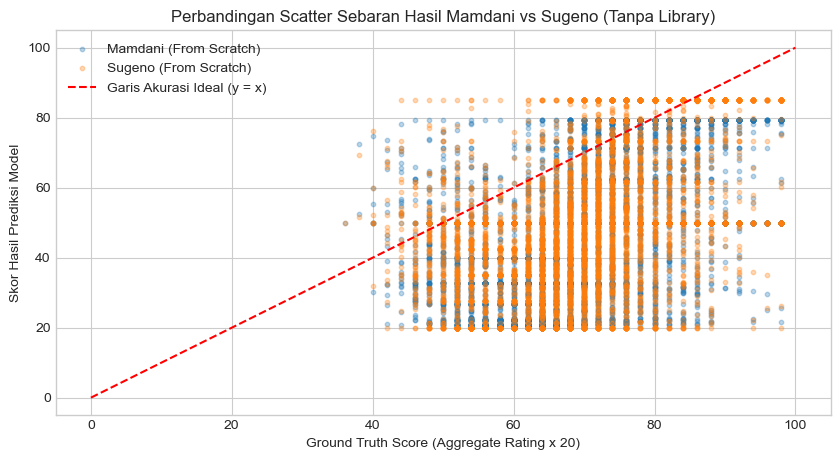

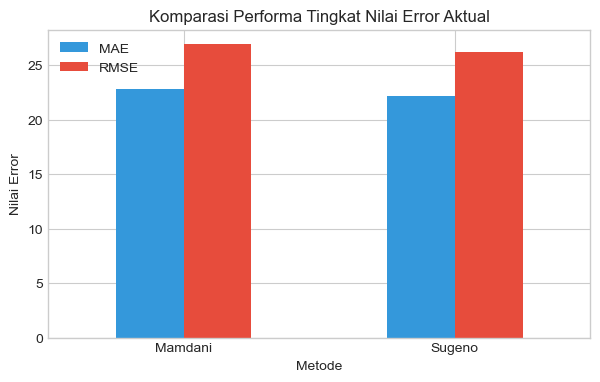

,Metode,MAE,RMSE
0,Mamdani,22.815217,26.903330
1,Sugeno,22.127033,26.226831


In [35]:
# Scatter Plot Perbandingan
plt.figure(figsize=(10, 5))
plt.scatter(data['GroundTruth_Score'], data['Mamdani_Score'], alpha=0.3, label='Mamdani (From Scratch)', s=10)
plt.scatter(data['GroundTruth_Score'], data['Sugeno_Score'], alpha=0.3, label='Sugeno (From Scratch)', s=10)
plt.plot([0, 100], [0, 100], 'r--', label='Garis Akurasi Ideal (y = x)')
plt.xlabel('Ground Truth Score (Aggregate Rating x 20)')
plt.ylabel('Skor Hasil Prediksi Model')
plt.title('Perbandingan Scatter Sebaran Hasil Mamdani vs Sugeno (Tanpa Library)')
plt.legend()
plt.show()

# Bar Chart Perbandingan MAE dan RMSE
metrics = pd.DataFrame({
    'Metode': ['Mamdani', 'Sugeno'],
    'MAE':  [mae_mamdani, mae_sugeno],
    'RMSE': [rmse_mamdani, rmse_sugeno]
})
metrics.set_index('Metode').plot(kind='bar', figsize=(7, 4), rot=0, color=['#3498db', '#e74c3c'])
plt.title('Komparasi Performa Tingkat Nilai Error Aktual')
plt.ylabel('Nilai Error')
plt.show()

display(metrics)